# COE 379L Software Engineering Design Project 1
## Austin Animal Shelter Data Analysis and Classification

This notebook performs exploratory data analysis and classification modeling on the Austin Animal Shelter dataset to predict outcome types (Transfer vs Adoption).

### Dataset Overview
The dataset contains 12 variables:
- AnimalID: ID given to the animal
- Date of Birth: Date of birth of animal  
- Name: Name of Animal
- DateTime: date and time of admission to the shelter
- MonthYear: month and year of admission to the shelter
- OutcomeType: Two classes Transfer or Adoption
- Outcome Subtype: More specific explanation of the Outcome Type
- Animal Type: Type of Animal
- Sex Upon Outcome: Animal's biological sex and reproductive status
- Age Upon Outcome: Animal's age upon outcome
- Breed: Breed of the animal
- Color: Color of the animal

## Part 1: Exploratory Data Analysis (8 points)

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
sns.set_palette("husl") #nice color scheme for matplotlib
%matplotlib inline

### 1. Identify shape, size of the raw data

In [2]:
#load dataset
df = pd.read_csv('project1.csv')

# information about the dataset
print("Dataset Shape:", df.shape)
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Total data points: {df.shape[0] * df.shape[1]}")

# Display first few rows to see what the data looks like
print("\nFirst 5 rows of the dataset:")
df.head()

Dataset Shape: (131165, 12)
Number of rows: 131165
Number of columns: 12
Total data points: 1573980

First 5 rows of the dataset:


,Animal ID,Date of Birth,Name,DateTime,MonthYear,Outcome Type,Outcome Subtype,Animal Type,Sex upon Outcome,Age upon Outcome,Breed,Color
0,A680855,5/25/14,NaN,2014-06-10T00:00:00-05:00,Jun-14,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black
1,A680857,5/25/14,NaN,2014-06-10T00:00:00-05:00,Jun-14,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black
2,A680858,5/25/14,NaN,2014-06-10T00:00:00-05:00,Jun-14,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black
3,A680859,5/25/14,NaN,2014-06-10T00:00:00-05:00,Jun-14,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black
4,A680860,5/25/14,NaN,2014-06-10T00:00:00-05:00,Jun-14,Transfer,Partner,Bird,Unknown,2 weeks,Duck,Yellow/Black


### 2. Get information about datatypes. Comment if any of the variables need datatype conversion. Check for duplicate rows and treat them.

In [3]:
# checking data types
print("Data types:")
print(df.dtypes)
print("\n" + "="*50)

# Check for duplicate rows
print(f"# of duplicate rows: {df.duplicated().sum()}")


# Display column information
print("\nColumn Information:")
print(df.info())

print("\n" + "="*50)
print("Data types that need conversion:")
print("- DateTime: Should be converted to datetime")
print("- Date of Birth: Should be converted to datetime") 
print("- Age upon Outcome: Should be converted to numeric (days)")
print("- Categorical variables need encoding (ex: Animal Type)")

Data types:
Animal ID           object
Date of Birth       object
Name                object
DateTime            object
MonthYear           object
Outcome Type        object
Outcome Subtype     object
Animal Type         object
Sex upon Outcome    object
Age upon Outcome    object
Breed               object
Color               object
dtype: object

# of duplicate rows: 17

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131165 entries, 0 to 131164
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Animal ID         131165 non-null  object
 1   Date of Birth     131165 non-null  object
 2   Name              93658 non-null   object
 3   DateTime          131165 non-null  object
 4   MonthYear         131165 non-null  object
 5   Outcome Type      131125 non-null  object
 6   Outcome Subtype   65810 non-null   object
 7   Animal Type       131165 non-null  object
 8   Sex upon Outcome  

### 3. Identify missing data and/or invalid values and treat them with suitable mean, median, mode or other method

In [4]:
# Check for missing values
print("Missing values per column:")
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
})
print(missing_df[missing_df['Missing Count'] > 0])

# Check empty strings and placeholder values
print("\nChecking for empty strings and placeholder values:")
for col in df.columns:
    if df[col].dtype == 'object':
        empty_count = (df[col] == '').sum()
        if empty_count > 0:
            print(f"{col}: {empty_count} empty strings ({(empty_count/len(df))*100:.2f}%)")

# Treatment of missing values
df_clean = df.copy()

#remove all the duplicate rows
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"\nRemoved {initial_rows - len(df_clean)} duplicate rows")

# fill in no name for missing name value since that is a common occurance
df_clean['Name'] = df_clean['Name'].fillna('No Name')

print(f"\nDataset shape after cleaning: {df_clean.shape}")

Missing values per column:
                 Missing Count
Name                     37507
Outcome Type                40
Outcome Subtype          65355

Checking for empty strings and placeholder values:

Removed 17 duplicate rows

Dataset shape after cleaning: (131148, 12)

Removed 17 duplicate rows

Dataset shape after cleaning: (131148, 12)


### 4. Visualize the dataset through different univariate analysis and comment on your observations

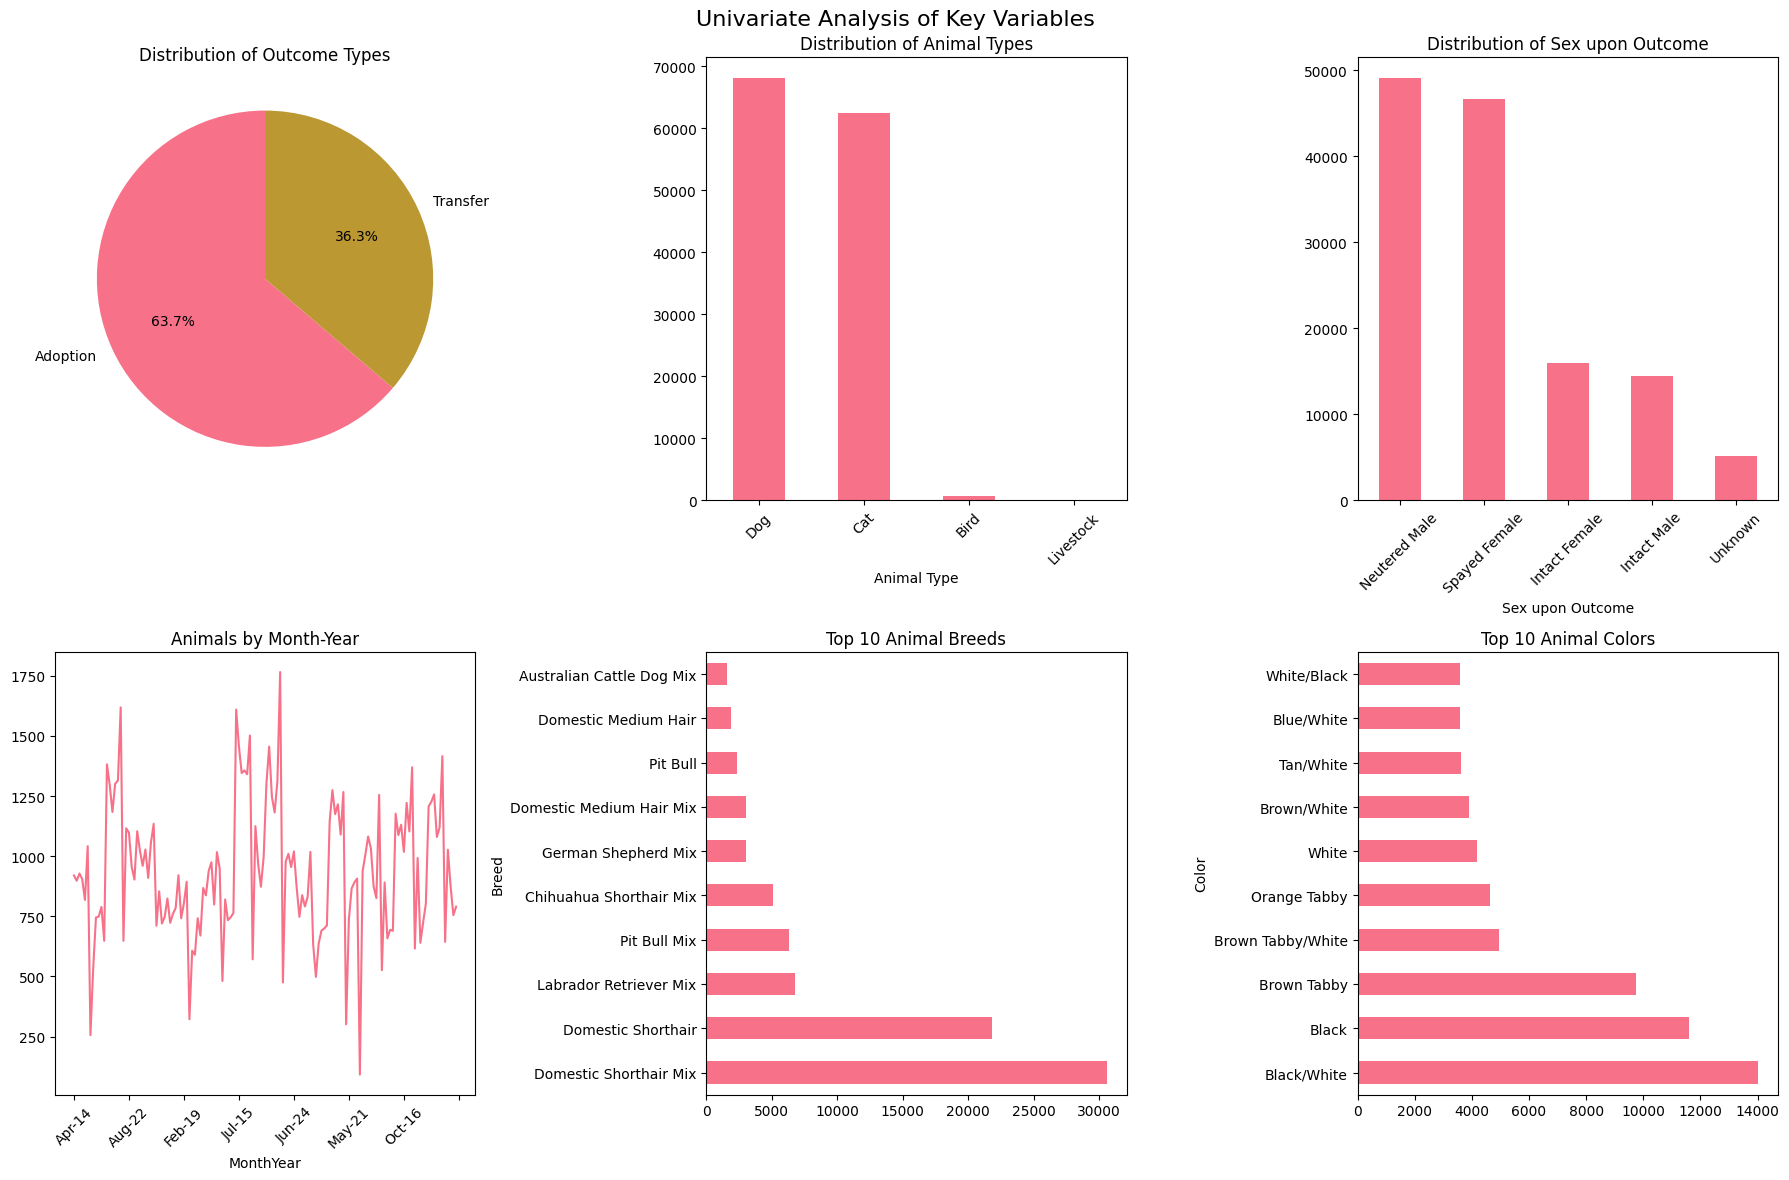

Key Observations from Univariate Analysis:
1. Outcome Type Distribution: {'Adoption': np.int64(83580), 'Transfer': np.int64(47528)}
2. Most common animal type: Dog
3. Most common sex status: Neutered Male
4. Most common breed: Domestic Shorthair Mix
5. Most common color: Black/White


In [5]:
# Set up for the plotting area
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Univariate Analysis of Key Variables', fontsize=16)

# 1. Outcome Type distribution
axes[0,0].pie(df_clean['Outcome Type'].value_counts(), labels=df_clean['Outcome Type'].value_counts().index, 
              autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribution of Outcome Types')

# 2. Animal Type distribution
df_clean['Animal Type'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Distribution of Animal Types')
axes[0,1].tick_params(axis='x', rotation=45)

# 3. Sex upon Outcome distribution
df_clean['Sex upon Outcome'].value_counts().plot(kind='bar', ax=axes[0,2])
axes[0,2].set_title('Distribution of Sex upon Outcome')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. MonthYear trends
monthly_counts = df_clean['MonthYear'].value_counts().sort_index()
monthly_counts.plot(kind='line', ax=axes[1,0])
axes[1,0].set_title('Animals by Month-Year')
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Top 10 breeds
top_breeds = df_clean['Breed'].value_counts().head(10)
top_breeds.plot(kind='barh', ax=axes[1,1])
axes[1,1].set_title('Top 10 Animal Breeds')

# 6. Top 10 colors
top_colors = df_clean['Color'].value_counts().head(10)
top_colors.plot(kind='barh', ax=axes[1,2])
axes[1,2].set_title('Top 10 Animal Colors')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Key Observations from Univariate Analysis:")
print(f"1. Outcome Type Distribution: {dict(df_clean['Outcome Type'].value_counts())}")
print(f"2. Most common animal type: {df_clean['Animal Type'].mode()[0]}")
print(f"3. Most common sex status: {df_clean['Sex upon Outcome'].mode()[0]}")
print(f"4. Most common breed: {df_clean['Breed'].mode()[0]}")
print(f"5. Most common color: {df_clean['Color'].mode()[0]}")

### 5. Drop duplicate rows and irrelevant columns. (already dropped duplicate rows)

In [6]:
# Find Irrelevant columns for prediction
print("Original columns:", df_clean.columns.tolist())

# Drop columns that are not useful for prediction
columns_to_drop = [
    'Animal ID',      # Unique identifier, not predictive
    'Date of Birth',  # We have age information
    'Name',          # names are not predictive
    'DateTime',      # already have MonthYear which is more useful for seasonality
    'Outcome Subtype' # too specific, might lead to overfitting
]

df_processed = df_clean.drop(columns=columns_to_drop)

print(f"\nColumns after dropping the ones irrelevant for prediction: {df_processed.columns.tolist()}")
print(f"Shape after column removal: {df_processed.shape}")

# Check the data types of remaining columns
print("\nRemaining columns and their types:")
for col in df_processed.columns:
    print(f"{col}: {df_processed[col].dtype} - {df_processed[col].nunique()} unique values")

Original columns: ['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']

Columns after dropping the ones irrelevant for prediction: ['MonthYear', 'Outcome Type', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']
Shape after column removal: (131148, 7)

Remaining columns and their types:
MonthYear: object - 140 unique values
Outcome Type: object - 2 unique values
Animal Type: object - 4 unique values
Sex upon Outcome: object - 5 unique values
Age upon Outcome: object - 45 unique values
Breed: object - 2527 unique values
Color: object - 599 unique values


### 6. Convert all data to numeric and/or categorical data types. Hint: Make the Age at Outcome column a float by converting all values to one unit for example days.

In [7]:
# convert age to days
def convert_age_to_days(age_str):
    """Convert age string to days float"""
    if pd.isna(age_str) or age_str == '':
        return np.nan
    
    age_str = str(age_str).lower().strip()
    
    # Extract number and unit
    parts = age_str.split()
    if len(parts) < 2:
        return np.nan
    
    try:
        number = float(parts[0])
        unit = parts[1]
        
        if 'day' in unit:
            return number
        elif 'week' in unit:
            return number * 7
        elif 'month' in unit:
            return number * 30.44  # Average days per month
        elif 'year' in unit:
            return number * 365.25  # .25 accounts for leap years
        else:
            return np.nan
    except:
        return np.nan

# apply age conversion
df_processed['Age_Days'] = df_processed['Age upon Outcome'].apply(convert_age_to_days)

# remove the original age column
df_processed = df_processed.drop('Age upon Outcome', axis=1)

# categorical columns converted  to category type
categorical_columns = ['MonthYear', 'Outcome Type', 'Animal Type', 'Sex upon Outcome', 'Breed', 'Color']
for col in categorical_columns:
    df_processed[col] = df_processed[col].astype('category')

print("Data types after conversion:")
print(df_processed.dtypes)

print(f"\nAge statistics (in days):")
print(df_processed['Age_Days'].describe())

# Check for any missing values just in case after conversion in Age_Days
print(f"\nMissing values in Age_Days: {df_processed['Age_Days'].isnull().sum()}")

# just fill the remaining missing ages with the median
median_age = df_processed['Age_Days'].median()
df_processed['Age_Days'] = df_processed['Age_Days'].fillna(median_age)
print(f"Filled missing ages with median: {median_age:.1f} days")

Data types after conversion:
MonthYear           category
Outcome Type        category
Animal Type         category
Sex upon Outcome    category
Breed               category
Color               category
Age_Days             float64
dtype: object

Age statistics (in days):
count    131148.000000
mean        576.098854
std         876.705018
min           1.000000
25%          60.880000
50%         243.520000
75%         730.500000
max       10957.500000
Name: Age_Days, dtype: float64

Missing values in Age_Days: 0
Filled missing ages with median: 243.5 days


### 7. Perform one-hot encoding on categorical variables

In [8]:
# target variable and features separation
target_col = 'Outcome Type'
y = df_processed[target_col]

# features to encode excluding target
features_to_encode = ['MonthYear', 'Animal Type', 'Sex upon Outcome', 'Breed', 'Color']

print("Original shape:", df_processed.shape)
print("Unique values in categorical columns:")
for col in features_to_encode:
    print(f"{col}: {df_processed[col].nunique()} unique values")


# Keep top 20 breeds and top 15 colors, group others as 'Other' since there are sooooo many
def reduce_categories(df, column, top_n):
    top_categories = df[column].value_counts().head(top_n).index
    df[column] = df[column].apply(lambda x: x if x in top_categories else 'Other')
    return df

df_encoded = df_processed.copy()
df_encoded = reduce_categories(df_encoded, 'Breed', 20)
df_encoded = reduce_categories(df_encoded, 'Color', 15)

print("\nAfter category reduction (reduced to keep only top 20 breeds and top 15 colors):")
for col in features_to_encode:
    print(f"{col}: {df_encoded[col].nunique()} unique values")

# one-hot encoding
df_final = pd.get_dummies(df_encoded, columns=features_to_encode, prefix=features_to_encode, drop_first=True)

print(f"\nFinal dataset shape after one-hot encoding: {df_final.shape}")
print(f"Number of features: {df_final.shape[1] - 1}")  # -1 for target column

# Display first few columns of the encoded dataset
print("\nFirst few columns of encoded dataset:")
print(df_final.columns[:10].tolist(), "... and", df_final.shape[1]-10, "more columns")

Original shape: (131148, 7)
Unique values in categorical columns:
MonthYear: 140 unique values
Animal Type: 4 unique values
Sex upon Outcome: 5 unique values
Breed: 2527 unique values
Color: 599 unique values

After category reduction (reduced to keep only top 20 breeds and top 15 colors):
MonthYear: 140 unique values
Animal Type: 4 unique values
Sex upon Outcome: 5 unique values
Breed: 21 unique values
Color: 16 unique values

Final dataset shape after one-hot encoding: (131148, 183)
Number of features: 182

First few columns of encoded dataset:
['Outcome Type', 'Age_Days', 'MonthYear_Apr-15', 'MonthYear_Apr-16', 'MonthYear_Apr-17', 'MonthYear_Apr-18', 'MonthYear_Apr-19', 'MonthYear_Apr-20', 'MonthYear_Apr-21', 'MonthYear_Apr-22'] ... and 173 more columns

Final dataset shape after one-hot encoding: (131148, 183)
Number of features: 182

First few columns of encoded dataset:
['Outcome Type', 'Age_Days', 'MonthYear_Apr-15', 'MonthYear_Apr-16', 'MonthYear_Apr-17', 'MonthYear_Apr-18', 'M

## Part 2: Fit Classification models on the data to predict the outcome type (OutcomeType)

In [9]:
# drop breed columns as instructed ('Breed_')
breed_columns = [col for col in df_final.columns if col.startswith('Breed_')]
print(f"Dropping {len(breed_columns)} breed-related columns: {breed_columns[:5]}...")

df_model = df_final.drop(columns=breed_columns)
print(f"Dataset shape after dropping breed columns: {df_model.shape}")

# X and y for modeling
X = df_model.drop('Outcome Type', axis=1)
y = df_model['Outcome Type']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"Target distribution (%):\n{y.value_counts(normalize=True)*100}")

# Check final feature names
print(f"\nFinal features ({X.shape[1]} total):")
print(X.columns.tolist())

Dropping 20 breed-related columns: ['Breed_Border Collie Mix', 'Breed_Boxer Mix', 'Breed_Chihuahua Shorthair', 'Breed_Chihuahua Shorthair Mix', 'Breed_Dachshund Mix']...
Dataset shape after dropping breed columns: (131148, 163)
Features shape: (131148, 162)
Target distribution:
Outcome Type
Adoption    83580
Transfer    47528
Name: count, dtype: int64
Target distribution (%):
Outcome Type
Adoption    63.74897
Transfer    36.25103
Name: proportion, dtype: float64

Final features (162 total):
['Age_Days', 'MonthYear_Apr-15', 'MonthYear_Apr-16', 'MonthYear_Apr-17', 'MonthYear_Apr-18', 'MonthYear_Apr-19', 'MonthYear_Apr-20', 'MonthYear_Apr-21', 'MonthYear_Apr-22', 'MonthYear_Apr-23', 'MonthYear_Apr-24', 'MonthYear_Apr-25', 'MonthYear_Aug-14', 'MonthYear_Aug-15', 'MonthYear_Aug-16', 'MonthYear_Aug-17', 'MonthYear_Aug-18', 'MonthYear_Aug-19', 'MonthYear_Aug-20', 'MonthYear_Aug-21', 'MonthYear_Aug-22', 'MonthYear_Aug-23', 'MonthYear_Aug-24', 'MonthYear_Dec-13', 'MonthYear_Dec-14', 'MonthYear_

### 1. Split the data into training and test datasets. Make sure your split is reproducible and that it maintains roughly the proportion of each class of dependent variable. 

In [10]:
# Remove NaN rows in features or target
Xy = pd.concat([X, y], axis=1)
Xy_clean = Xy.dropna()
X_clean = Xy_clean.drop(columns=[y.name])
y_clean = Xy_clean[y.name]

# stratified train-test split to maintain class proportions
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_clean
)

print("Train-Test Split Results:")
print(f"Training set size: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set size: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True)*100)

print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True)*100)

# Scale features for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures scaled using StandardScaler")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Test features shape: {X_test_scaled.shape}")

Train-Test Split Results:
Training set size: 104886 (80.0%)
Test set size: 26222 (20.0%)

Class distribution in training set:
Outcome Type
Adoption    63.749213
Transfer    36.250787
Name: proportion, dtype: float64

Class distribution in test set:
Outcome Type
Adoption    63.747998
Transfer    36.252002
Name: proportion, dtype: float64
Outcome Type
Adoption    63.749213
Transfer    36.250787
Name: proportion, dtype: float64

Class distribution in test set:
Outcome Type
Adoption    63.747998
Transfer    36.252002
Name: proportion, dtype: float64

Features scaled using StandardScaler
Training features shape: (104886, 162)
Test features shape: (26222, 162)

Features scaled using StandardScaler
Training features shape: (104886, 162)
Test features shape: (26222, 162)


### 2. K-Nearest Neighbor Classifier

K-Nearest Neighbor Classifier (k=5) Results:
Accuracy: 0.8173

Classification Report:
              precision    recall  f1-score   support

    Adoption       0.82      0.91      0.86     16716
    Transfer       0.81      0.65      0.72      9506

    accuracy                           0.82     26222
   macro avg       0.81      0.78      0.79     26222
weighted avg       0.82      0.82      0.81     26222

              precision    recall  f1-score   support

    Adoption       0.82      0.91      0.86     16716
    Transfer       0.81      0.65      0.72      9506

    accuracy                           0.82     26222
   macro avg       0.81      0.78      0.79     26222
weighted avg       0.82      0.82      0.81     26222



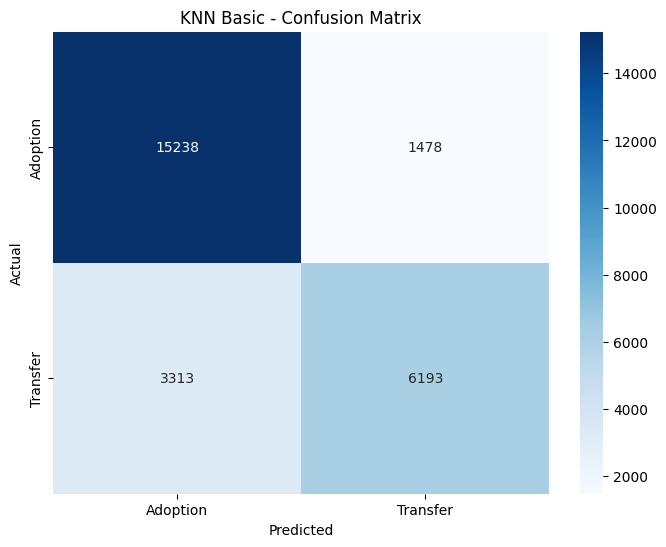

In [11]:
# KNN Classifier
knn_basic = KNeighborsClassifier(n_neighbors=5)
knn_basic.fit(X_train_scaled, y_train)

# predictions
y_pred_knn_basic = knn_basic.predict(X_test_scaled)

# accuracy
accuracy_knn_basic = accuracy_score(y_test, y_pred_knn_basic)

print("K-Nearest Neighbor Classifier (k=5) Results:")
print(f"Accuracy: {accuracy_knn_basic:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_basic))

# Confusion Matrix
cm_knn_basic = confusion_matrix(y_test, y_pred_knn_basic)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_basic, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Adoption', 'Transfer'], 
            yticklabels=['Adoption', 'Transfer'])
plt.title('KNN Basic - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 3. K-Nearest Neighbor Classifier using Grid search CV 

Grid Search for optimal KNN parameters
Fitting 5 folds for each of 5 candidates, totalling 25 fits

Best parameters: {'n_neighbors': 3}

Best parameters: {'n_neighbors': 3}

KNN Grid Search Results:
Test Accuracy: 0.8149

Classification Report:
              precision    recall  f1-score   support

    Adoption       0.83      0.89      0.86     16716
    Transfer       0.78      0.68      0.73      9506

    accuracy                           0.81     26222
   macro avg       0.81      0.79      0.79     26222
weighted avg       0.81      0.81      0.81     26222


KNN Grid Search Results:
Test Accuracy: 0.8149

Classification Report:
              precision    recall  f1-score   support

    Adoption       0.83      0.89      0.86     16716
    Transfer       0.78      0.68      0.73      9506

    accuracy                           0.81     26222
   macro avg       0.81      0.79      0.79     26222
weighted avg       0.81      0.81      0.81     26222



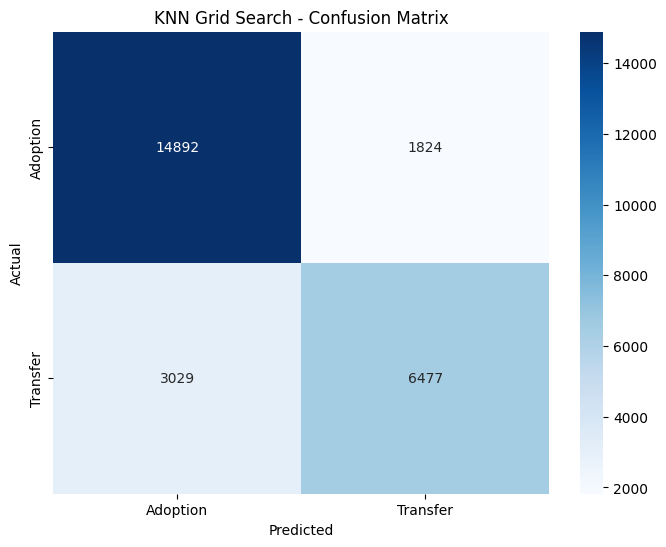

In [12]:
# KNN with Grid Search CV
print("Grid Search for optimal KNN parameters")

# parameter grid
param_grid_knn = {"n_neighbors": [3, 5, 7, 9, 11]}

# Initialize KNN classifier
knn_grid = KNeighborsClassifier()

# Perform Grid Search with "5" cross-validation (what we talked about 9/30 lecture)
grid_search_knn = GridSearchCV(
    knn_grid, 
    param_grid_knn, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Fit grid search
grid_search_knn.fit(X_train_scaled, y_train)

# Get best parameters and score
print(f"\nBest parameters: {grid_search_knn.best_params_}")

# Make predictions with best model
y_pred_knn_grid = grid_search_knn.predict(X_test_scaled)

# accuracy
accuracy_knn_grid = accuracy_score(y_test, y_pred_knn_grid)

print(f"\nKNN Grid Search Results:")
print(f"Test Accuracy: {accuracy_knn_grid:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_grid))

# Confusion Matrix
cm_knn_grid = confusion_matrix(y_test, y_pred_knn_grid)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn_grid, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Adoption', 'Transfer'], 
            yticklabels=['Adoption', 'Transfer'])
plt.title('KNN Grid Search - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### 4. Linear Classification (1 point)


Linear Classification (Perceptron) Results:
Accuracy: 0.8094
Decision function range: [-5658.434, 523.871]
Number of near-boundary points: 29

Classification Report:
              precision    recall  f1-score   support

    Adoption       0.83      0.88      0.85     16716
    Transfer       0.76      0.69      0.72      9506

    accuracy                           0.81     26222
   macro avg       0.80      0.78      0.79     26222
weighted avg       0.81      0.81      0.81     26222



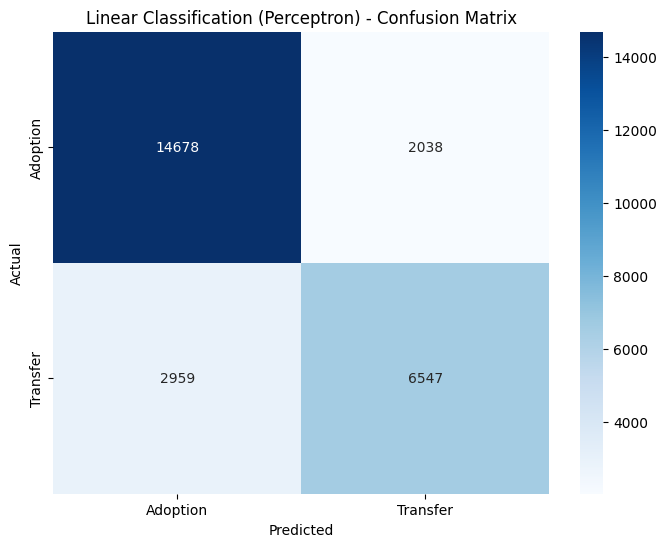


Linear Separability Analysis:
- Classes: [np.str_('Adoption'), np.str_('Transfer')]
- Coefficients shape: (1, 162)
- Intercept (bias term): -48.0000
- Model found not fully linearly separable boundary


In [13]:
# === Linear Classification with Perceptron ===
from sklearn.linear_model import Perceptron

# perceptron linear classifier from class notes
perc = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
perc.fit(X_train_scaled, y_train)

#predictions and decision function
y_pred_perc = perc.predict(X_test_scaled)
decision_scores = perc.decision_function(X_test_scaled)

#accuracy
accuracy_perc = accuracy_score(y_test, y_pred_perc)

print("\nLinear Classification (Perceptron) Results:")
print(f"Accuracy: {accuracy_perc:.4f}")
print(f"Decision function range: [{decision_scores.min():.3f}, {decision_scores.max():.3f}]")
print(f"Number of near-boundary points: {len(decision_scores[abs(decision_scores) < 0.1])}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_perc))

# Confusion Matrix
cm_perc = confusion_matrix(y_test, y_pred_perc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_perc, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Adoption', 'Transfer'],
            yticklabels=['Adoption', 'Transfer'])
plt.title('Linear Classification (Perceptron) - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Linear separability analysis
print("\nLinear Separability Analysis:")
print(f"- Classes: {list(perc.classes_)}")
print(f"- Coefficients shape: {perc.coef_.shape}")
print(f"- Intercept (bias term): {perc.intercept_[0]:.4f}")
print(f"- Model found {'linearly separable' if accuracy_perc > 0.95 else 'not fully linearly separable'} boundary")


### 5. Model Performance Comparison and Metric Analysis (2 points)

Model Performance Comparison:
          Model  Accuracy  Precision  Recall  F1-Score
KNN Basic (k=5)    0.8173     0.8163  0.8173    0.8123
KNN Grid Search    0.8149     0.8126  0.8149    0.8119
     Perceptron    0.8094     0.8070  0.8094    0.8071


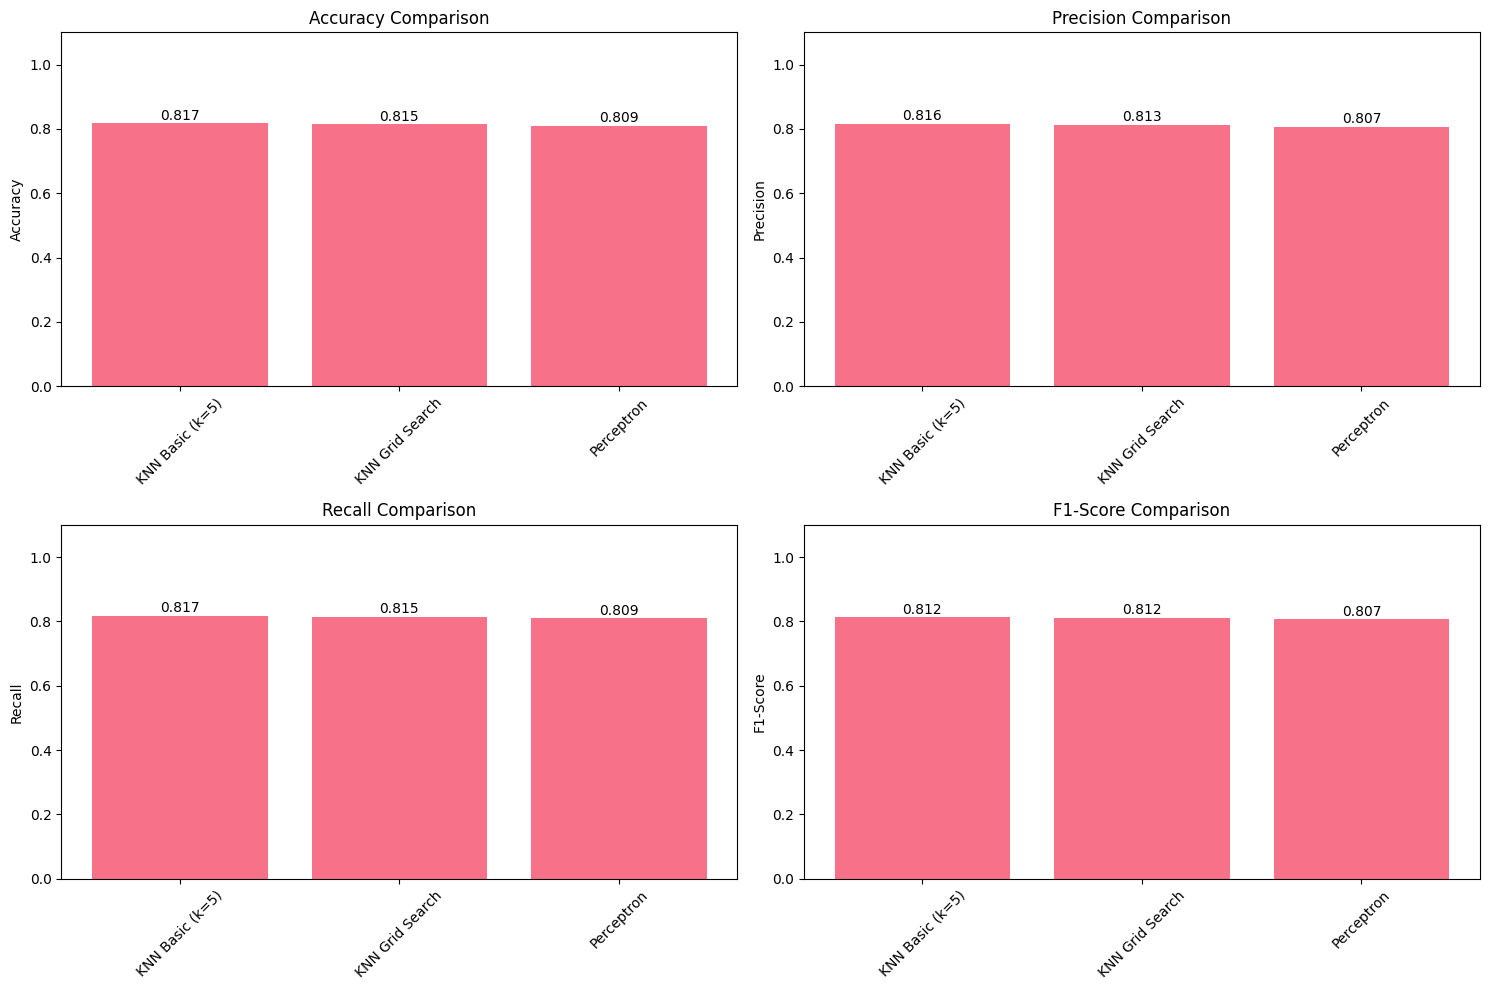

- Best Accuracy: KNN Basic (k=5) (0.8173)
- Best Precision: KNN Basic (k=5) (0.8163)
- Best Recall: KNN Basic (k=5) (0.8173)
- Best F1-Score: KNN Basic (k=5) (0.8123)

Overall Recommendation: KNN Basic (k=5) appears to be the best balanced model.


In [14]:
# metrics for all models
from sklearn.metrics import precision_score, recall_score, f1_score

models = {
    'KNN Basic (k=5)': y_pred_knn_basic,
    'KNN Grid Search': y_pred_knn_grid, 
    'Perceptron': y_pred_perc
}

results = []

for model_name, predictions in models.items():
    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions, average='weighted')
    recall = recall_score(y_test, predictions, average='weighted')
    f1 = f1_score(y_test, predictions, average='weighted')
    
    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# comparison DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("Model Performance Comparison:")
print(results_df.to_string(index=False))

# model comparison plot
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    bars = ax.bar(results_df['Model'], results_df[metric])
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=45)
    
    # value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.001,
                f'{height:.3f}', ha='center', va='bottom')
    
    ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

# best model for each metric
best_models = {}
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_idx = results_df[metric].idxmax()
    best_models[metric] = results_df.loc[best_idx, 'Model']
    print(f"- Best {metric}: {best_models[metric]} ({results_df.loc[best_idx, metric]:.4f})")

print(f"\nOverall Recommendation: {best_models['F1-Score']} appears to be the best balanced model.")